In [ ]:
pip install rdkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.1/37.1 MB 17.2 MB/s eta 0:00:00


In [ ]:
! wget "https://raw.githubusercontent.com/kush021104/QSAR-based-DPP4-CADD-MODEL/refs/heads/main/DPP4%20raw%20data%20chembl%201%20(1).csv"

--2026-05-31 11:05:11--  https://raw.githubusercontent.com/kush021104/QSAR-based-DPP4-CADD-MODEL/refs/heads/main/DPP4%20raw%20data%20chembl%201%20(1).csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 394130 (385K) [text/plain]
Saving to: ‘DPP4 raw data chembl 1 (1).csv’

DPP4 raw data chemb 100%[===================>] 384.89K  --.-KB/s    in 0.03s   

2026-05-31 11:05:12 (11.5 MB/s) - ‘DPP4 raw data chembl 1 (1).csv’ saved [394130/394130]



In [ ]:
import pandas as pd

df = pd.read_csv('DPP4 raw data chembl 1 (1).csv')
df

,molecule_chembl_id,canonical_smiles,standard_value,class
0,CHEMBL93558,N[C@@H](CC1CCCCC1)C(=O)N1CCCCC1,217000.0,inactive
1,CHEMBL443622,C[C@H](N)C(=O)N1CCCC1,41000.0,inactive
2,CHEMBL403882,O=C([C@@H]1CCCN1)N1CCCC1,15000.0,inactive
3,CHEMBL328655,S=C(C1CCCN1)N1CCCC1,500000.0,inactive
4,CHEMBL328795,NC(=O)CC(N)C(=O)N1CCCC1,188000.0,inactive
...,...,...,...,...
4691,CHEMBL5947027,C[C@H](NC(=O)c1ccncc1-c1ccccc1)C(=O)N1CC(F)(F)...,1000.0,active
4692,CHEMBL6014809,CC[C@@H](C)C(N)C(=O)N1Cc2ccc(F)cc2C1,7900.0,intermediate
4693,CHEMBL5874480,CC(C)[C@H](N)C(=O)N1Cc2ccc(F)cc2C1,20270.0,inactive
4694,CHEMBL6060914,CC(C)(C)[C@H](N)C(=O)N1Cc2ccc(F)cc2C1,9818.0,intermediate


In [ ]:
df_no_smiles = df.drop(columns='canonical_smiles')

In [ ]:
smiles = []

for i in df.canonical_smiles.tolist():
  cpd = str(i).split('.')
  cpd_longest = max(cpd, key = len)
  smiles.append(cpd_longest)

smiles = pd.Series(smiles, name = 'canonical_smiles')

In [ ]:
df_clean_smiles = pd.concat([df_no_smiles,smiles], axis=1)
df_clean_smiles

,molecule_chembl_id,standard_value,class,canonical_smiles
0,CHEMBL93558,217000.0,inactive,N[C@@H](CC1CCCCC1)C(=O)N1CCCCC1
1,CHEMBL443622,41000.0,inactive,C[C@H](N)C(=O)N1CCCC1
2,CHEMBL403882,15000.0,inactive,O=C([C@@H]1CCCN1)N1CCCC1
3,CHEMBL328655,500000.0,inactive,S=C(C1CCCN1)N1CCCC1
4,CHEMBL328795,188000.0,inactive,NC(=O)CC(N)C(=O)N1CCCC1
...,...,...,...,...
4691,CHEMBL5947027,1000.0,active,C[C@H](NC(=O)c1ccncc1-c1ccccc1)C(=O)N1CC(F)(F)...
4692,CHEMBL6014809,7900.0,intermediate,CC[C@@H](C)C(N)C(=O)N1Cc2ccc(F)cc2C1
4693,CHEMBL5874480,20270.0,inactive,CC(C)[C@H](N)C(=O)N1Cc2ccc(F)cc2C1
4694,CHEMBL6060914,9818.0,intermediate,CC(C)(C)[C@H](N)C(=O)N1Cc2ccc(F)cc2C1


In [ ]:
import numpy as np
from rdkit import Chem
from rdkit.Chem import Descriptors, Lipinski


In [ ]:
def lipinski(smiles, verbose=False):

    moldata= []
    for elem in smiles:
        mol=Chem.MolFromSmiles(elem)
        moldata.append(mol)

    baseData= np.arange(1,1)
    i=0
    for mol in moldata:

        desc_MolWt = Descriptors.MolWt(mol)
        desc_MolLogP = Descriptors.MolLogP(mol)
        desc_NumHDonors = Lipinski.NumHDonors(mol)
        desc_NumHAcceptors = Lipinski.NumHAcceptors(mol)

        row = np.array([desc_MolWt,
                        desc_MolLogP,
                        desc_NumHDonors,
                        desc_NumHAcceptors])

        if(i==0):
            baseData=row
        else:
            baseData=np.vstack([baseData, row])
        i=i+1

    columnNames=["MW","LogP","NumHDonors","NumHAcceptors"]
    descriptors = pd.DataFrame(data=baseData,columns=columnNames)

    return descriptors

In [ ]:
df_lipinski = lipinski(df_clean_smiles.canonical_smiles)
df_lipinski

,MW,LogP,NumHDonors,NumHAcceptors
0,238.375,2.29660,1.0,2.0
1,142.202,-0.04400,1.0,2.0
2,168.240,0.36080,1.0,2.0
3,184.308,1.16160,1.0,2.0
4,185.227,-1.18850,2.0,3.0
...,...,...,...,...
4691,384.386,2.62668,1.0,4.0
4692,250.317,2.04130,1.0,2.0
4693,236.290,1.65120,1.0,2.0
4694,250.317,2.04130,1.0,2.0


In [ ]:
df_lipinski

,MW,LogP,NumHDonors,NumHAcceptors
0,238.375,2.29660,1.0,2.0
1,142.202,-0.04400,1.0,2.0
2,168.240,0.36080,1.0,2.0
3,184.308,1.16160,1.0,2.0
4,185.227,-1.18850,2.0,3.0
...,...,...,...,...
4691,384.386,2.62668,1.0,4.0
4692,250.317,2.04130,1.0,2.0
4693,236.290,1.65120,1.0,2.0
4694,250.317,2.04130,1.0,2.0


In [ ]:
df

,molecule_chembl_id,canonical_smiles,standard_value,class
0,CHEMBL93558,N[C@@H](CC1CCCCC1)C(=O)N1CCCCC1,217000.0,inactive
1,CHEMBL443622,C[C@H](N)C(=O)N1CCCC1,41000.0,inactive
2,CHEMBL403882,O=C([C@@H]1CCCN1)N1CCCC1,15000.0,inactive
3,CHEMBL328655,S=C(C1CCCN1)N1CCCC1,500000.0,inactive
4,CHEMBL328795,NC(=O)CC(N)C(=O)N1CCCC1,188000.0,inactive
...,...,...,...,...
4691,CHEMBL5947027,C[C@H](NC(=O)c1ccncc1-c1ccccc1)C(=O)N1CC(F)(F)...,1000.0,active
4692,CHEMBL6014809,CC[C@@H](C)C(N)C(=O)N1Cc2ccc(F)cc2C1,7900.0,intermediate
4693,CHEMBL5874480,CC(C)[C@H](N)C(=O)N1Cc2ccc(F)cc2C1,20270.0,inactive
4694,CHEMBL6060914,CC(C)(C)[C@H](N)C(=O)N1Cc2ccc(F)cc2C1,9818.0,intermediate


In [ ]:
df_combined = pd.concat([df,df_lipinski], axis=1)
df_combined

,molecule_chembl_id,canonical_smiles,standard_value,class,MW,LogP,NumHDonors,NumHAcceptors
0,CHEMBL93558,N[C@@H](CC1CCCCC1)C(=O)N1CCCCC1,217000.0,inactive,238.375,2.29660,1.0,2.0
1,CHEMBL443622,C[C@H](N)C(=O)N1CCCC1,41000.0,inactive,142.202,-0.04400,1.0,2.0
2,CHEMBL403882,O=C([C@@H]1CCCN1)N1CCCC1,15000.0,inactive,168.240,0.36080,1.0,2.0
3,CHEMBL328655,S=C(C1CCCN1)N1CCCC1,500000.0,inactive,184.308,1.16160,1.0,2.0
4,CHEMBL328795,NC(=O)CC(N)C(=O)N1CCCC1,188000.0,inactive,185.227,-1.18850,2.0,3.0
...,...,...,...,...,...,...,...,...
4691,CHEMBL5947027,C[C@H](NC(=O)c1ccncc1-c1ccccc1)C(=O)N1CC(F)(F)...,1000.0,active,384.386,2.62668,1.0,4.0
4692,CHEMBL6014809,CC[C@@H](C)C(N)C(=O)N1Cc2ccc(F)cc2C1,7900.0,intermediate,250.317,2.04130,1.0,2.0
4693,CHEMBL5874480,CC(C)[C@H](N)C(=O)N1Cc2ccc(F)cc2C1,20270.0,inactive,236.290,1.65120,1.0,2.0
4694,CHEMBL6060914,CC(C)(C)[C@H](N)C(=O)N1Cc2ccc(F)cc2C1,9818.0,intermediate,250.317,2.04130,1.0,2.0


In [ ]:
import numpy as np

def pIC50(input):
    pIC50 = []

    for i in input['standard_value_norm']:
        molar = i*(10**-9) # Converts nM to M
        pIC50.append(-np.log10(molar))

    input['pIC50'] = pIC50
    x = input.drop('standard_value_norm', axis=1)

    return x

In [ ]:
df_combined.standard_value.describe()

,standard_value
count,4.696000e+03
mean,4.098398e+05
std,1.642462e+07
min,5.000000e-02
25%,1.500000e+01
50%,1.100000e+02
75%,3.000000e+03
max,1.100000e+09


In [ ]:

-np.log10( (10**-9)* 100000000 )


np.float64(1.0)

In [ ]:
-np.log10( (10**-9)* 10000000000 )

np.float64(-1.0)

In [ ]:
def norm_value(input):
    norm = []

    for i in input['standard_value']:
        if i > 100000000:
          i = 100000000
        norm.append(i)

    input['standard_value_norm'] = norm
    x = input.drop('standard_value', axis=1)

    return x

In [ ]:
df_norm = norm_value(df_combined)
df_norm

,molecule_chembl_id,canonical_smiles,class,MW,LogP,NumHDonors,NumHAcceptors,standard_value_norm
0,CHEMBL93558,N[C@@H](CC1CCCCC1)C(=O)N1CCCCC1,inactive,238.375,2.29660,1.0,2.0,217000.0
1,CHEMBL443622,C[C@H](N)C(=O)N1CCCC1,inactive,142.202,-0.04400,1.0,2.0,41000.0
2,CHEMBL403882,O=C([C@@H]1CCCN1)N1CCCC1,inactive,168.240,0.36080,1.0,2.0,15000.0
3,CHEMBL328655,S=C(C1CCCN1)N1CCCC1,inactive,184.308,1.16160,1.0,2.0,500000.0
4,CHEMBL328795,NC(=O)CC(N)C(=O)N1CCCC1,inactive,185.227,-1.18850,2.0,3.0,188000.0
...,...,...,...,...,...,...,...,...
4691,CHEMBL5947027,C[C@H](NC(=O)c1ccncc1-c1ccccc1)C(=O)N1CC(F)(F)...,active,384.386,2.62668,1.0,4.0,1000.0
4692,CHEMBL6014809,CC[C@@H](C)C(N)C(=O)N1Cc2ccc(F)cc2C1,intermediate,250.317,2.04130,1.0,2.0,7900.0
4693,CHEMBL5874480,CC(C)[C@H](N)C(=O)N1Cc2ccc(F)cc2C1,inactive,236.290,1.65120,1.0,2.0,20270.0
4694,CHEMBL6060914,CC(C)(C)[C@H](N)C(=O)N1Cc2ccc(F)cc2C1,intermediate,250.317,2.04130,1.0,2.0,9818.0


In [ ]:

df_norm.standard_value_norm.describe()

,standard_value_norm
count,4.696000e+03
mean,1.968926e+05
std,3.782370e+06
min,5.000000e-02
25%,1.500000e+01
50%,1.100000e+02
75%,3.000000e+03
max,1.000000e+08


In [ ]:
df_final = pIC50(df_norm)
df_final

,molecule_chembl_id,canonical_smiles,class,MW,LogP,NumHDonors,NumHAcceptors,pIC50
0,CHEMBL93558,N[C@@H](CC1CCCCC1)C(=O)N1CCCCC1,inactive,238.375,2.29660,1.0,2.0,3.663540
1,CHEMBL443622,C[C@H](N)C(=O)N1CCCC1,inactive,142.202,-0.04400,1.0,2.0,4.387216
2,CHEMBL403882,O=C([C@@H]1CCCN1)N1CCCC1,inactive,168.240,0.36080,1.0,2.0,4.823909
3,CHEMBL328655,S=C(C1CCCN1)N1CCCC1,inactive,184.308,1.16160,1.0,2.0,3.301030
4,CHEMBL328795,NC(=O)CC(N)C(=O)N1CCCC1,inactive,185.227,-1.18850,2.0,3.0,3.725842
...,...,...,...,...,...,...,...,...
4691,CHEMBL5947027,C[C@H](NC(=O)c1ccncc1-c1ccccc1)C(=O)N1CC(F)(F)...,active,384.386,2.62668,1.0,4.0,6.000000
4692,CHEMBL6014809,CC[C@@H](C)C(N)C(=O)N1Cc2ccc(F)cc2C1,intermediate,250.317,2.04130,1.0,2.0,5.102373
4693,CHEMBL5874480,CC(C)[C@H](N)C(=O)N1Cc2ccc(F)cc2C1,inactive,236.290,1.65120,1.0,2.0,4.693146
4694,CHEMBL6060914,CC(C)(C)[C@H](N)C(=O)N1Cc2ccc(F)cc2C1,intermediate,250.317,2.04130,1.0,2.0,5.007977


In [ ]:
df_final.pIC50.describe()


,pIC50
count,4696.000000
mean,6.631718
std,1.614939
min,1.000000
25%,5.522879
50%,6.958607
75%,7.823909
max,10.301030


In [ ]:
df_final.to_csv('DPP4_04_bioactivity_data_3class_pIC50.csv')


In [ ]:
df_2class = df_final[df_final['class'] != 'intermediate']
df_2class

,molecule_chembl_id,canonical_smiles,class,MW,LogP,NumHDonors,NumHAcceptors,pIC50
0,CHEMBL93558,N[C@@H](CC1CCCCC1)C(=O)N1CCCCC1,inactive,238.375,2.29660,1.0,2.0,3.663540
1,CHEMBL443622,C[C@H](N)C(=O)N1CCCC1,inactive,142.202,-0.04400,1.0,2.0,4.387216
2,CHEMBL403882,O=C([C@@H]1CCCN1)N1CCCC1,inactive,168.240,0.36080,1.0,2.0,4.823909
3,CHEMBL328655,S=C(C1CCCN1)N1CCCC1,inactive,184.308,1.16160,1.0,2.0,3.301030
4,CHEMBL328795,NC(=O)CC(N)C(=O)N1CCCC1,inactive,185.227,-1.18850,2.0,3.0,3.725842
...,...,...,...,...,...,...,...,...
4689,CHEMBL5858334,CNC(=O)c1ccc(-c2ccc3nccc(C(=O)NCC(=O)N4CC(F)(F...,active,495.461,2.89008,2.0,5.0,6.000000
4690,CHEMBL5822886,C[C@@H](NC(=O)c1ccncc1-c1ccccc1)C(=O)N1CC(F)(F...,active,384.386,2.62668,1.0,4.0,6.000000
4691,CHEMBL5947027,C[C@H](NC(=O)c1ccncc1-c1ccccc1)C(=O)N1CC(F)(F)...,active,384.386,2.62668,1.0,4.0,6.000000
4693,CHEMBL5874480,CC(C)[C@H](N)C(=O)N1Cc2ccc(F)cc2C1,inactive,236.290,1.65120,1.0,2.0,4.693146


In [ ]:

df_2class.to_csv('DPP4_05_bioactivity_data_2class_pIC50.csv')

In [ ]:
import seaborn as sns
sns.set(style='ticks')
import matplotlib.pyplot as plt

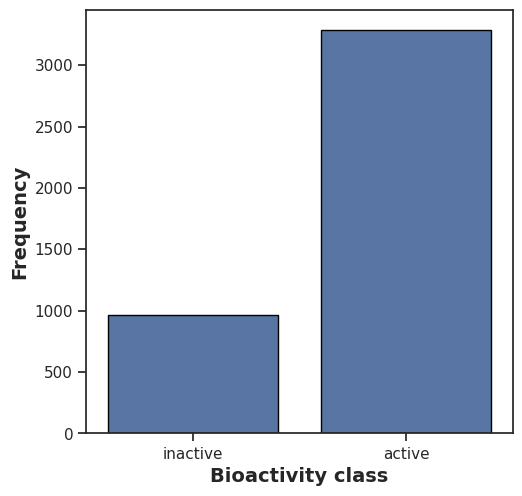

In [ ]:
plt.figure(figsize=(5.5, 5.5))

sns.countplot(x='class', data=df_2class, edgecolor='black')

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('Frequency', fontsize=14, fontweight='bold')

plt.savefig('plot_bioactivity_class.pdf')

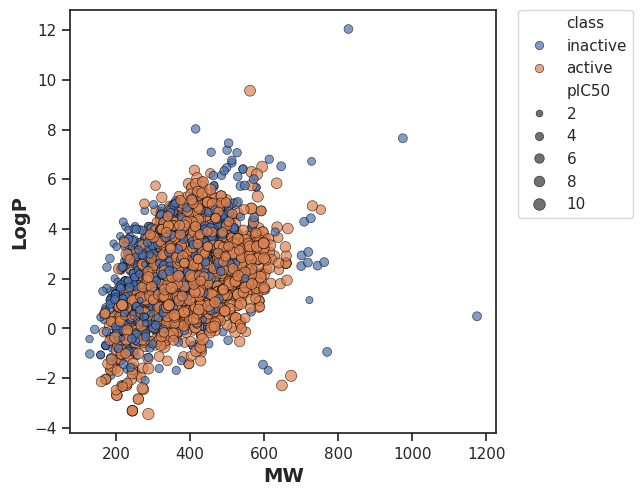

In [ ]:
plt.figure(figsize=(5.5, 5.5))

sns.scatterplot(x='MW', y='LogP', data=df_2class, hue='class', size='pIC50', edgecolor='black', alpha=0.7)

plt.xlabel('MW', fontsize=14, fontweight='bold')
plt.ylabel('LogP', fontsize=14, fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0)
plt.savefig('plot_MW_vs_LogP.pdf')

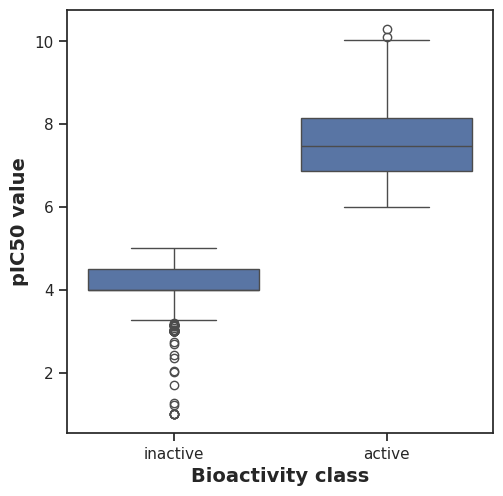

In [ ]:
plt.figure(figsize=(5.5, 5.5))

sns.boxplot(x = 'class', y = 'pIC50', data = df_2class)

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('pIC50 value', fontsize=14, fontweight='bold')

plt.savefig('plot_ic50.pdf')

In [ ]:

def mannwhitney(descriptor, verbose=False):
  # https://machinelearningmastery.com/nonparametric-statistical-significance-tests-in-python/
  from numpy.random import seed
  from numpy.random import randn
  from scipy.stats import mannwhitneyu

# seed the random number generator
  seed(1)

# actives and inactives
  selection = [descriptor, 'class']
  df = df_2class[selection]
  active = df[df['class'] == 'active']
  active = active[descriptor]

  selection = [descriptor, 'class']
  df = df_2class[selection]
  inactive = df[df['class'] == 'inactive']
  inactive = inactive[descriptor]

# compare samples
  stat, p = mannwhitneyu(active, inactive)
  #print('Statistics=%.3f, p=%.3f' % (stat, p))

# interpret
  alpha = 0.05
  if p > alpha:
    interpretation = 'Same distribution (fail to reject H0)'
  else:
    interpretation = 'Different distribution (reject H0)'

  results = pd.DataFrame({'Descriptor':descriptor,
                          'Statistics':stat,
                          'p':p,
                          'alpha':alpha,
                          'Interpretation':interpretation}, index=[0])
  filename = 'mannwhitneyu_' + descriptor + '.csv'
  results.to_csv(filename)

  return results

In [ ]:
mannwhitney('pIC50')

,Descriptor,Statistics,p,alpha,Interpretation
0,pIC50,3156480.0,0.0,0.05,Different distribution (reject H0)


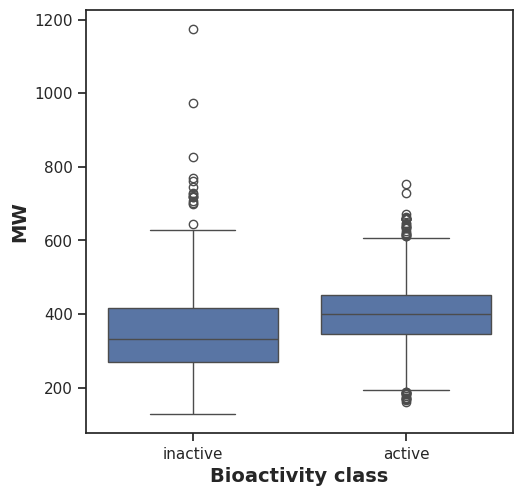

In [ ]:
plt.figure(figsize=(5.5, 5.5))

sns.boxplot(x = 'class', y = 'MW', data = df_2class)

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('MW', fontsize=14, fontweight='bold')

plt.savefig('plot_MW.pdf')

In [ ]:
mannwhitney('MW')

,Descriptor,Statistics,p,alpha,Interpretation
0,MW,2101970.0,2.591129e-55,0.05,Different distribution (reject H0)


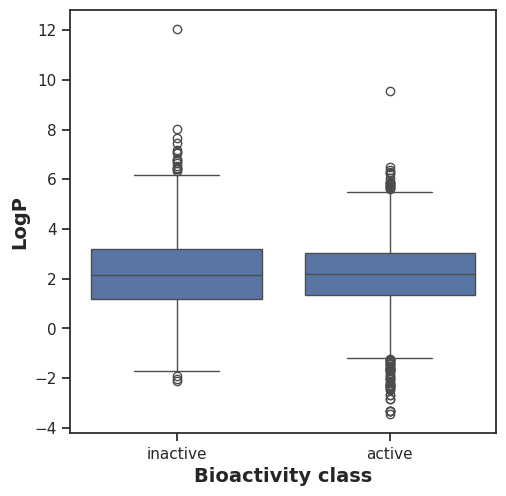

In [ ]:
plt.figure(figsize=(5.5, 5.5))

sns.boxplot(x = 'class', y = 'LogP', data = df_2class)

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('LogP', fontsize=14, fontweight='bold')

plt.savefig('plot_LogP.pdf')

In [ ]:
mannwhitney('LogP')


,Descriptor,Statistics,p,alpha,Interpretation
0,LogP,1574019.0,0.899539,0.05,Same distribution (fail to reject H0)


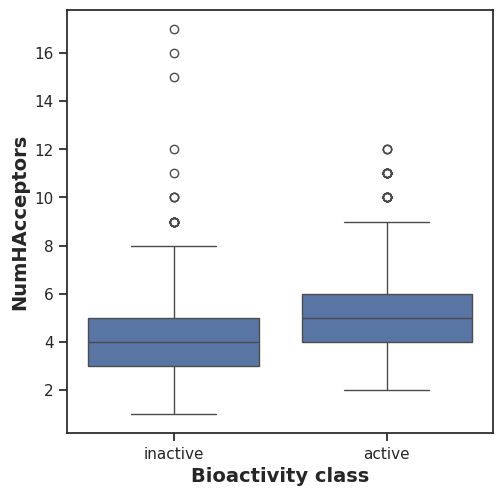

In [ ]:
plt.figure(figsize=(5.5, 5.5))

sns.boxplot(x = 'class', y = 'NumHAcceptors', data = df_2class)

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('NumHAcceptors', fontsize=14, fontweight='bold')

plt.savefig('plot_NumHAcceptors.pdf')

In [ ]:
mannwhitney('NumHAcceptors')

,Descriptor,Statistics,p,alpha,Interpretation
0,NumHAcceptors,1942007.0,1.206251e-28,0.05,Different distribution (reject H0)


In [ ]:

! zip -r results.zip . -i *.csv *.pdf

  adding: mannwhitneyu_NumHAcceptors.csv (deflated 11%)
  adding: mannwhitneyu_LogP.csv (deflated 7%)
  adding: plot_MW.pdf (deflated 38%)
  adding: plot_ic50.pdf (deflated 37%)
  adding: plot_NumHAcceptors.pdf (deflated 38%)
  adding: mannwhitneyu_pIC50.csv (deflated 8%)
  adding: plot_LogP.pdf (deflated 37%)
  adding: plot_bioactivity_class.pdf (deflated 38%)
  adding: DPP4_05_bioactivity_data_2class_pIC50.csv (deflated 79%)
  adding: DPP4 raw data chembl 1 (1).csv (deflated 84%)
  adding: mannwhitneyu_MW.csv (deflated 9%)
  adding: DPP4_04_bioactivity_data_3class_pIC50.csv (deflated 79%)
  adding: plot_MW_vs_LogP.pdf (deflated 2%)
